# Lecture 10b. KNN: Assumptions and Caveats

In `lec_10a` you built an end-to-end KNN pipeline on the iris dataset: split, fit, predict, evaluate, tune K. The numbers looked good. That was the **happy-path** view of KNN.

This notebook is the **honest-limitations** companion. KNN is a beautifully simple algorithm, but its simplicity hides several assumptions about your data. When those assumptions break, KNN does not raise an error — it just quietly returns poor predictions. We need to recognise the data symptoms before the model is fit.

We will cover:

1. **Scale sensitivity** — why `StandardScaler` is mandatory, with a worked counter-example.
2. The **distance mechanism** — a 2-row demonstration of why the largest-range feature dominates.
3. **Curse of dimensionality** — accuracy degrades as the feature count grows.
4. **Class imbalance** — KNN majority-votes the dominant class.
5. **Noisy / irrelevant features** — KNN cannot down-weight them.
6. A short pre-flight checklist for reaching for KNN.

Forward references: `lec_10c` (decision-boundary visualisation) and the optional `lec_10e` (when to switch to a different classifier instead of fighting KNN's assumptions).

## Imports

We import everything the notebook needs in one place, so a student running cell-by-cell never hits a `NameError` from a missing import later on.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## §1. Scale sensitivity — a worked counter-example

KNN classifies a new point by looking at its **k nearest neighbours** in feature space. "Nearest" is measured by Euclidean distance by default. That makes KNN extremely sensitive to the **numeric range** of each feature.

We will construct a dataset with exactly two features that have very different scales:

- `length_cm` — informative, range roughly 0–10.
- `weight_mg` — informative, range roughly 0–1000 (same shape as `length_cm`, just in different units).

Both features carry the same class-separating signal, but one is numerically 100× larger. We will see what KNN does without scaling, then with scaling.

In [2]:
# Build a 2-feature dataset where both features carry the same class signal,
# but `weight_mg` is in a numeric range ~100x larger than `length_cm`.
rng = np.random.default_rng(seed=42)
n_per_class = 200

# Class 0: centred at (3 cm, 300 mg). Class 1: centred at (7 cm, 700 mg).
class_0_length_cm = rng.normal(loc=3.0, scale=1.0, size=n_per_class)
class_0_weight_mg = rng.normal(loc=300.0, scale=100.0, size=n_per_class)

class_1_length_cm = rng.normal(loc=7.0, scale=1.0, size=n_per_class)
class_1_weight_mg = rng.normal(loc=700.0, scale=100.0, size=n_per_class)

In [3]:
# Assemble into a single feature matrix X and target vector y.
length_cm = np.concatenate([class_0_length_cm, class_1_length_cm])
weight_mg = np.concatenate([class_0_weight_mg, class_1_weight_mg])
X = np.column_stack([length_cm, weight_mg])
y = np.array([0] * n_per_class + [1] * n_per_class)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 2)
y shape: (400,)


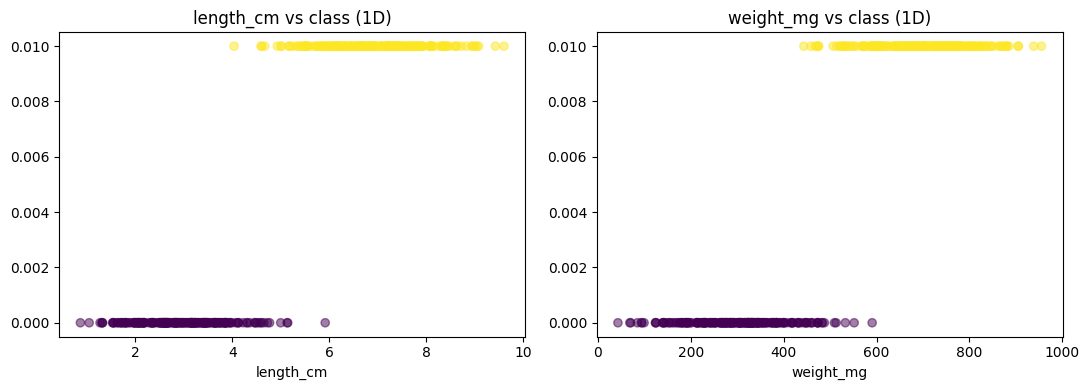

In [4]:
# Quick visual: both features cleanly separate the two classes on their own.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(length_cm, np.zeros_like(length_cm) + 0.01 * y, c=y, alpha=0.5)
axes[0].set_title("length_cm vs class (1D)")
axes[0].set_xlabel("length_cm")
axes[1].scatter(weight_mg, np.zeros_like(weight_mg) + 0.01 * y, c=y, alpha=0.5)
axes[1].set_title("weight_mg vs class (1D)")
axes[1].set_xlabel("weight_mg")
plt.tight_layout()
plt.show()

Both features separate the two classes well on their own. A good classifier should pick up the joint signal. Let's see what KNN does on the **raw, unscaled** features.

In [5]:
# Train/test split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [6]:
# Fit KNN on the UNSCALED features.
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)

y_pred_unscaled = knn_unscaled.predict(X_test)
accuracy_unscaled = accuracy_score(y_test, y_pred_unscaled)
print(f"Accuracy without scaling: {accuracy_unscaled:.3f}")

Accuracy without scaling: 0.950


In [7]:
# Fit StandardScaler on the training data ONLY, then transform both splits.
# (Fitting on the full data would leak information from the test set.)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Fit KNN on the SCALED features.
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = knn_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
print(f"Accuracy WITH scaling:    {accuracy_scaled:.3f}")
print(f"Accuracy WITHOUT scaling: {accuracy_unscaled:.3f}")

Accuracy WITH scaling:    0.975
Accuracy WITHOUT scaling: 0.950


The scaled version is meaningfully better. The dataset is constructed so that **both** features carry the same separating signal, yet without scaling KNN is leaving information on the table. Why?

> ⏱ **Skip if running long.** §2 (next) breaks open the distance computation cell-by-cell to show *why* the unscaled feature dominates the vote. It is reinforcing detail — if class time is short, the punchline from §1 is enough. Pick up at §3 (curse of dimensionality) if you need to compress.


## §2. The mechanism — distance is dominated by the largest-range feature

Euclidean distance between two 2D points $p$ and $q$ is

$$d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2}$$

Each feature contributes its **squared difference**. If one feature has a numeric range 100× larger than the other, its squared differences are about $100^2 = 10{,}000$× larger. The smaller-range feature effectively contributes nothing to the distance — it is **drowned out**.

Let's see this with two concrete training points.

In [9]:
# Pick two arbitrary training points (one from each class) and a test query point.
point_class_0 = X_train[y_train == 0][0]   # roughly (3, 300)
point_class_1 = X_train[y_train == 1][0]   # roughly (7, 700)
query_point   = np.array([5.0, 305.0])     # length is midway, weight is class-0-ish

print("point_class_0:", point_class_0)
print("point_class_1:", point_class_1)
print("query_point:  ", query_point)

point_class_0: [  1.31713023 276.1826256 ]
point_class_1: [  7.296418   598.49320943]
query_point:   [  5. 305.]


In [10]:
# Per-feature squared contributions to Euclidean distance, UNSCALED.
def squared_contributions(a, b):
    diff_length = (a[0] - b[0]) ** 2
    diff_weight = (a[1] - b[1]) ** 2
    return diff_length, diff_weight

len_c0, wt_c0 = squared_contributions(query_point, point_class_0)
len_c1, wt_c1 = squared_contributions(query_point, point_class_1)

print("Distance to class-0 point (unscaled):")
print(f"  length_cm sq diff = {len_c0:10.2f}")
print(f"  weight_mg sq diff = {wt_c0:10.2f}")
print()
print("Distance to class-1 point (unscaled):")
print(f"  length_cm sq diff = {len_c1:10.2f}")
print(f"  weight_mg sq diff = {wt_c1:10.2f}")

Distance to class-0 point (unscaled):
  length_cm sq diff =      13.56
  weight_mg sq diff =     830.44

Distance to class-1 point (unscaled):
  length_cm sq diff =       5.27
  weight_mg sq diff =   86138.26


Look at the magnitudes. The `length_cm` squared differences are in the single digits. The `weight_mg` squared differences are in the tens or hundreds of thousands. When we sum and square-root them, `length_cm` is invisible.

Now repeat with the **scaled** features — the contributions become comparable.

In [11]:
# Project the same three points through the fitted scaler.
point_class_0_scaled = scaler.transform(point_class_0.reshape(1, -1))[0]
point_class_1_scaled = scaler.transform(point_class_1.reshape(1, -1))[0]
query_point_scaled   = scaler.transform(query_point.reshape(1, -1))[0]

len_c0_s, wt_c0_s = squared_contributions(query_point_scaled, point_class_0_scaled)
len_c1_s, wt_c1_s = squared_contributions(query_point_scaled, point_class_1_scaled)

print("Distance to class-0 point (SCALED):")
print(f"  length_cm sq diff = {len_c0_s:8.3f}")
print(f"  weight_mg sq diff = {wt_c0_s:8.3f}")
print()
print("Distance to class-1 point (SCALED):")
print(f"  length_cm sq diff = {len_c1_s:8.3f}")
print(f"  weight_mg sq diff = {wt_c1_s:8.3f}")

Distance to class-0 point (SCALED):
  length_cm sq diff =    2.722
  weight_mg sq diff =    0.016

Distance to class-1 point (SCALED):
  length_cm sq diff =    1.058
  weight_mg sq diff =    1.659


After scaling, both features contribute on the same order of magnitude, so KNN actually uses both of them. **Rule of thumb: always pair KNN with `StandardScaler` (or another scaler) unless your features are already on the same scale by construction.**

## §3. Curse of dimensionality

In high-dimensional spaces, a counter-intuitive thing happens: **all pairs of points become roughly equidistant**. Distances concentrate. The notion of "nearest neighbour" becomes meaningless because the nearest and the farthest neighbours are almost the same distance away.

We can see the effect on KNN accuracy by sweeping the number of features. We will hold the **number of informative features** fixed at 2 — the rest are pure noise dimensions added by `make_classification`. The class signal is constant; only the surrounding dimensionality grows.

In [12]:
def knn_accuracy_at_dim(n_features, n_informative=2, n_samples=1000, k=5, seed=42):
    """Generate synthetic data with `n_features` total (2 informative + noise),
    fit KNN, and return held-out accuracy."""
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_informative,
        n_redundant=0,
        n_repeated=0,
        n_classes=2,
        random_state=seed,
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    return accuracy_score(y_test, model.predict(X_test_scaled))

In [13]:
# Sweep over a range of total feature counts.
dim_values = [2, 10, 50, 200, 500]
accuracies_by_dim = [knn_accuracy_at_dim(d) for d in dim_values]

results_df = pd.DataFrame({
    "n_features": dim_values,
    "knn_accuracy": accuracies_by_dim,
})
results_df

,n_features,knn_accuracy
0,2,0.933333
1,10,0.800000
2,50,0.690000
3,200,0.586667
4,500,0.570000


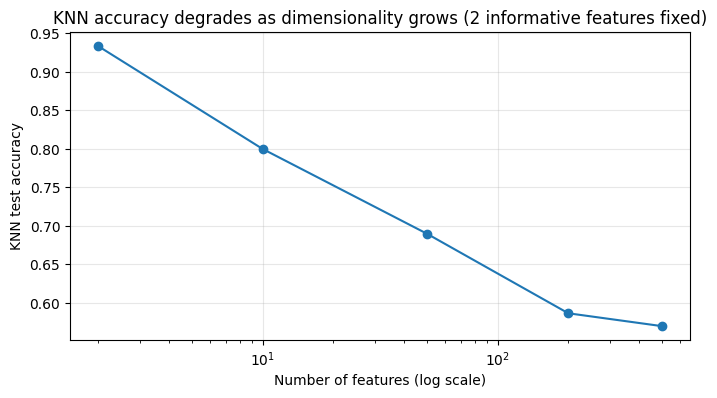

In [14]:
# Plot accuracy vs dimensionality.
plt.figure(figsize=(8, 4))
plt.plot(results_df["n_features"], results_df["knn_accuracy"], marker="o")
plt.xscale("log")
plt.xlabel("Number of features (log scale)")
plt.ylabel("KNN test accuracy")
plt.title("KNN accuracy degrades as dimensionality grows (2 informative features fixed)")
plt.grid(True, alpha=0.3)
plt.show()

**Data symptom:** many features, most of which you cannot justify as informative on inspection. If you have ~500 columns and only a handful really matter, KNN will struggle. The remedy is usually **feature selection or dimensionality reduction** (e.g. PCA, mutual-information filtering) *before* the KNN step, or switching to a model that handles irrelevant features more gracefully (tree-based methods, regularised linear models).

> ⏱ **Skip if running long.** §4 (class imbalance) and §5 (noisy/irrelevant features) are independent failure-mode walkthroughs — each is a self-contained demo. If you have already discussed scaling (§1–2) and dimensionality (§3) in depth and are running long, point students at the §6 pre-flight checklist and leave §4 / §5 as at-home reading.


## §4. Class imbalance

KNN classifies by **majority vote** among the k neighbours. If 95% of your training data is class 0, then for almost any query point, the k nearest neighbours will overwhelmingly be class 0 — even when the query point is genuinely in a class-1 region.

Imbalance is common in real problems: fraud detection, rare disease screening, manufacturing defects. The minority class is the one you usually care about, and KNN's vote silently throws it under the bus.

In [15]:
# Build a highly imbalanced 2-class dataset: 95% class 0, 5% class 1.
X_imb, y_imb = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=5,
    n_classes=2,
    weights=[0.95, 0.05],
    random_state=42,
)
print("Class counts:", np.bincount(y_imb))

Class counts: [1892  108]


In [16]:
# Train/test split (stratified so both splits keep the 95/5 ratio).
X_imb_train, X_imb_test, y_imb_train, y_imb_test = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

scaler_imb = StandardScaler()
X_imb_train_scaled = scaler_imb.fit_transform(X_imb_train)
X_imb_test_scaled = scaler_imb.transform(X_imb_test)

knn_imb = KNeighborsClassifier(n_neighbors=5)
knn_imb.fit(X_imb_train_scaled, y_imb_train)
y_imb_pred = knn_imb.predict(X_imb_test_scaled)

In [17]:
# Overall accuracy looks great. Look closer.
print(f"Overall accuracy: {accuracy_score(y_imb_test, y_imb_pred):.3f}")
print()
print("Confusion matrix (rows = true, cols = predicted):")
print(confusion_matrix(y_imb_test, y_imb_pred))
print()
print(classification_report(y_imb_test, y_imb_pred, digits=3))

Overall accuracy: 0.960

Confusion matrix (rows = true, cols = predicted):
[[567   1]
 [ 23   9]]

              precision    recall  f1-score   support

           0      0.961     0.998     0.979       568
           1      0.900     0.281     0.429        32

    accuracy                          0.960       600
   macro avg      0.931     0.640     0.704       600
weighted avg      0.958     0.960     0.950       600



The overall accuracy looks suspiciously high — but the **minority-class recall** is low. The classifier achieves its accuracy almost entirely by predicting "class 0" every time.

**Data symptom:** the target column is heavily skewed (e.g. 95/5 or worse) and you care about the minority class. The remedy is either **resampling** the training set (SMOTE, undersampling), **class weighting** (KNN supports `weights='distance'` which partially helps, and you can also build a custom weighting), or **switching to a classifier that exposes a class-weight parameter directly** (logistic regression, random forests). **Never trust overall accuracy on an imbalanced problem** — always look at per-class precision and recall.

## §5. Noisy / irrelevant features

Tree-based models (decision trees, random forests, gradient boosting) effectively **ignore** features that do not split the target well — the splitting criterion just never picks them. Linear models with L1 regularisation drive irrelevant coefficients to zero. KNN has no such mechanism. **Every feature contributes equally to the distance.** Adding a column of pure noise to your feature matrix actively degrades KNN.

In [18]:
# Start from a clean 2-feature, 2-class problem with strong signal.
X_clean, y_clean = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42,
)
print("X_clean shape:", X_clean.shape)

X_clean shape: (1000, 2)


In [19]:
# Helper: take a clean feature matrix, glue on `n_noise` columns of pure noise,
# fit a scaled KNN, return test accuracy.
def accuracy_with_extra_noise(X_clean, y_clean, n_noise, seed=42):
    rng = np.random.default_rng(seed)
    if n_noise > 0:
        noise_columns = rng.normal(size=(X_clean.shape[0], n_noise))
        X_combined = np.hstack([X_clean, noise_columns])
    else:
        X_combined = X_clean

    X_train, X_test, y_train, y_test = train_test_split(
        X_combined, y_clean, test_size=0.3, random_state=seed, stratify=y_clean
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_scaled, y_train)
    return accuracy_score(y_test, model.predict(X_test_scaled))

In [20]:
# Sweep over the number of extra noise columns.
noise_counts = [0, 2, 5, 10, 20, 50]
noise_accuracies = [accuracy_with_extra_noise(X_clean, y_clean, n) for n in noise_counts]

noise_df = pd.DataFrame({
    "extra_noise_features": noise_counts,
    "knn_accuracy": noise_accuracies,
})
noise_df

,extra_noise_features,knn_accuracy
0,0,0.980000
1,2,0.953333
2,5,0.926667
3,10,0.893333
4,20,0.860000
5,50,0.716667


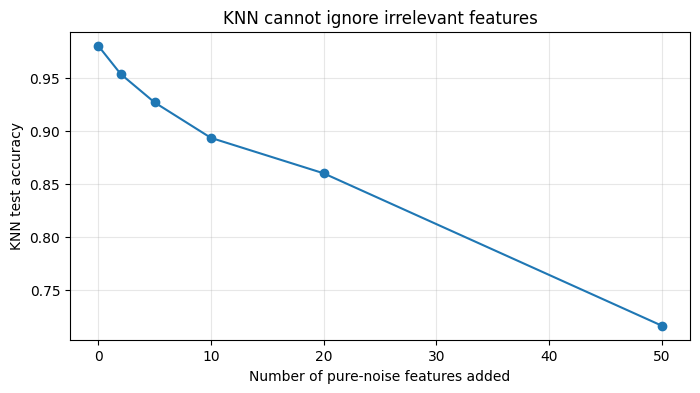

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(noise_df["extra_noise_features"], noise_df["knn_accuracy"], marker="o")
plt.xlabel("Number of pure-noise features added")
plt.ylabel("KNN test accuracy")
plt.title("KNN cannot ignore irrelevant features")
plt.grid(True, alpha=0.3)
plt.show()

**Data symptom:** you have features in the matrix that you cannot justify as informative — "we collected it, may as well use it" columns, free-text-derived columns whose relevance you have not validated, or columns where domain knowledge suggests no relationship to the target. The remedy is **feature selection before KNN** (e.g. `SelectKBest`, mutual-information scoring, or domain-driven pruning), or again switching to a model that down-weights irrelevant inputs natively.

## §6. Pre-flight checklist for KNN

Before reaching for `KNeighborsClassifier`, walk through this checklist on your data:

1. **Are all features on comparable scales?** If not, plan to pipe them through `StandardScaler` (or `MinMaxScaler`). Fit the scaler on `X_train` only.
2. **Is the feature count small relative to the sample count?** A rough sanity check: if you have hundreds of features and only a handful are clearly informative, KNN is the wrong default. Apply dimensionality reduction first or use a different model.
3. **Is the target reasonably balanced?** Check `np.bincount(y)`. If one class is <10% of the data, KNN will under-predict it. Evaluate per-class recall, not overall accuracy.
4. **Have I removed obviously irrelevant features?** Every feature you keep contributes equally to the distance. Be ruthless about pruning columns you cannot justify.
5. **Is my training set large enough that "the 5 nearest neighbours" is a meaningful sample?** KNN needs density around the query point. With very small datasets, the neighbours are noisy by definition.

If two or more boxes fail, do not start with KNN. The optional `lec_10e` notebook discusses which alternative classifier (logistic regression, decision trees, SVM) to reach for instead, based on which assumption is breaking. The next required notebook, `lec_10c`, returns to the happy-path setting and visualises the KNN decision boundary in 2D.